# SPOTIFY DATA ANALYTICS

# Objective:
Analyze Spotify data to uncover insights about music trends,user preferences, and song characteristics.

In [1]:
# importing mojor libraries
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import plotly.express as px
from textblob import TextBlob

# addition libraries 
import warnings
warnings.filterwarnings('ignore')

# Task 1.1: Overview of the Project and Its Objectives

This project focuses on analyzing Spotify music data to uncover meaningful patterns, trends, and insights related to songs, artists, genres, and listener preferences. With the rapid growth of digital music streaming, platforms like Spotify generate vast amounts of data that can be used to understand what makes songs popular, how musical styles evolve over time, and how user tastes vary across genres and artists.

The main goal of this project is to apply exploratory data analysis (EDA) and data-driven techniques to examine the characteristics of tracks and identify relationships between audio features and popularity. By analyzing attributes such as danceability, energy, tempo, loudness, and valence, the project aims to understand how musical properties influence audience engagement and trends.

## Objectives
- Explore and clean the Spotify datasets for analysis
- Analyze track-level audio features and their distributions
- Identify trends across artists, genres, and years
- Examine how musical characteristics affect popularity
- Discover patterns in listener preferences and genre performance
- Generate insights and recommendations using data visualization and statistical analysis

Overall, the project demonstrates how data analytics can be used to better understand the music industry and listener behavior.

# Task 1.2: Explanation of the Dataset Used

The project uses multiple Spotify datasets containing detailed information about tracks, artists, genres, and yearly trends. These datasets provide both musical attributes and metadata that support comprehensive analysis.

## Datasets Included
### 1. Track-level Dataset (data.csv)

This dataset contains information about individual songs available on Spotify. Each row represents a track with various audio and popularity features.

**Key attributes include:**
- Track name and artist
- Popularity score
- Duration
- Danceability
- Energy
- Loudness
- Speechiness
- Acousticness
- Instrumentalness
- Liveness
- Valence (musical positivity)
- Tempo

This dataset is primarily used to analyze how audio characteristics influence song popularity and listener engagement.

### 2. Artist-level Dataset (data_by_artist.csv)

This dataset aggregates features at the artist level by averaging track characteristics for each artist.

Used to:
- Compare artists based on their musical style
- Identify high-performing or popular artists
- Analyze consistency in audio features across an artist’s songs

### 3. Genre-level Dataset (data_by_genres.csv)

This dataset groups tracks by genre and provides averaged audio features.

Used to:
- Study differences between musical genres
- Identify dominant genre traits (e.g., energetic vs acoustic genres)
- Compare genre popularity

### 4. Yearly Dataset (data_by_year.csv)

This dataset summarizes music trends over time by year.

Used to:
- Analyze how music characteristics evolve across years
- Observe changes in popularity, tempo, or energy over time
- Detect historical trends in the music industry

### 5. Tracks with Genres Dataset (data_w_genres.csv)

This dataset links tracks with their associated genres, enabling more detailed analysis.

Used to:
- Connect individual tracks to genre categories
- Perform combined track + genre analysis
- Improve genre-based recommendations and comparisons

## Summary
Together, these datasets provide a comprehensive view of Spotify music data at multiple levels — track, artist, genre, and time. This multi-dimensional structure enables deeper insights into musical patterns, listener preferences, and evolving trends in the music industry.

In [2]:
tracks = pd.read_csv('data.csv')
artist = pd.read_csv('data_by_artist.csv')
genres = pd.read_csv('data_by_genres.csv')
year = pd.read_csv('data_by_year.csv')
tracks_genres = pd.read_csv('data_w_genres.csv')

# Data Collection and Preprocessing 
**Task 2.1:** Load the dataset into the Jupyter notebook.

**Task 2.2:** Inspect and clean the data (handle missing values, duplicates, etc.).

**Task 2.3:** Perform exploratory data analysis (EDA) to understand the basic characteristics of the data

In [3]:
artist.head()

,mode,count,acousticness,artists,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,9,0.590111,"""Cats"" 1981 Original London Cast",0.467222,250318.555556,0.394003,0.011400,0.290833,-14.448000,0.210389,117.518111,0.389500,38.333333,5
1,1,26,0.862538,"""Cats"" 1983 Broadway Cast",0.441731,287280.000000,0.406808,0.081158,0.315215,-10.690000,0.176212,103.044154,0.268865,30.576923,5
2,1,7,0.856571,"""Fiddler On The Roof” Motion Picture Chorus",0.348286,328920.000000,0.286571,0.024593,0.325786,-15.230714,0.118514,77.375857,0.354857,34.857143,0
3,1,27,0.884926,"""Fiddler On The Roof” Motion Picture Orchestra",0.425074,262890.962963,0.245770,0.073587,0.275481,-15.639370,0.123200,88.667630,0.372030,34.851852,0
4,1,7,0.510714,"""Joseph And The Amazing Technicolor Dreamcoat""...",0.467143,270436.142857,0.488286,0.009400,0.195000,-10.236714,0.098543,122.835857,0.482286,43.000000,5


In [4]:
genres.head()

,mode,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,21st century classical,0.979333,0.162883,1.602977e+05,0.071317,0.606834,0.361600,-31.514333,0.040567,75.336500,0.103783,27.833333,6
1,1,432hz,0.494780,0.299333,1.048887e+06,0.450678,0.477762,0.131000,-16.854000,0.076817,120.285667,0.221750,52.500000,5
2,1,8-bit,0.762000,0.712000,1.151770e+05,0.818000,0.876000,0.126000,-9.180000,0.047000,133.444000,0.975000,48.000000,7
3,1,[],0.651417,0.529093,2.328809e+05,0.419146,0.205309,0.218696,-12.288965,0.107872,112.857352,0.513604,20.859882,7
4,1,a cappella,0.676557,0.538961,1.906285e+05,0.316434,0.003003,0.172254,-12.479387,0.082851,112.110362,0.448249,45.820071,7


In [5]:
year.head()

,mode,year,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,1921,0.886896,0.418597,260537.166667,0.231815,0.344878,0.205710,-17.048667,0.073662,101.531493,0.379327,0.653333,2
1,1,1922,0.938592,0.482042,165469.746479,0.237815,0.434195,0.240720,-19.275282,0.116655,100.884521,0.535549,0.140845,10
2,1,1923,0.957247,0.577341,177942.362162,0.262406,0.371733,0.227462,-14.129211,0.093949,114.010730,0.625492,5.389189,0
3,1,1924,0.940200,0.549894,191046.707627,0.344347,0.581701,0.235219,-14.231343,0.092089,120.689572,0.663725,0.661017,10
4,1,1925,0.962607,0.573863,184986.924460,0.278594,0.418297,0.237668,-14.146414,0.111918,115.521921,0.621929,2.604317,5


In [6]:
tracks_genres.head()

,genres,artists,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key,mode,count
0,['show tunes'],"""Cats"" 1981 Original London Cast",0.590111,0.467222,250318.555556,0.394003,0.011400,0.290833,-14.448000,0.210389,117.518111,0.389500,38.333333,5,1,9
1,[],"""Cats"" 1983 Broadway Cast",0.862538,0.441731,287280.000000,0.406808,0.081158,0.315215,-10.690000,0.176212,103.044154,0.268865,30.576923,5,1,26
2,[],"""Fiddler On The Roof” Motion Picture Chorus",0.856571,0.348286,328920.000000,0.286571,0.024593,0.325786,-15.230714,0.118514,77.375857,0.354857,34.857143,0,1,7
3,[],"""Fiddler On The Roof” Motion Picture Orchestra",0.884926,0.425074,262890.962963,0.245770,0.073587,0.275481,-15.639370,0.123200,88.667630,0.372030,34.851852,0,1,27
4,[],"""Joseph And The Amazing Technicolor Dreamcoat""...",0.510714,0.467143,270436.142857,0.488286,0.009400,0.195000,-10.236714,0.098543,122.835857,0.482286,43.000000,5,1,7


In [7]:
tracks.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.381,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.229,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665


In [8]:
print(tracks.info())
print('-'*50)
print(artist.info())
print('-'*50)
print(genres.info())
print('-'*50)
print(year.info())
print('-'*50)
print(tracks_genres.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

In [9]:
print(tracks.isnull().sum())
print('-'*50)
print(artist.isnull().sum())
print('-'*50)
print(genres.isnull().sum())
print('-'*50)
print(year.isnull().sum())
print('-'*50)
print(tracks_genres.isnull().sum())

valence             0
year                0
acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
explicit            0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
name                0
popularity          0
release_date        0
speechiness         0
tempo               0
dtype: int64
--------------------------------------------------
mode                0
count               0
acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
key                 0
dtype: int64
--------------------------------------------------
mode                0
genres              0
acousticness        0
danceability        0
duration_ms         0
energy        

In [10]:
# Fill numeric missing values with mean
tracks.fillna(tracks.mean(numeric_only=True), inplace=True)
artist.fillna(artist.mean(numeric_only=True), inplace=True)
genres.fillna(genres.mean(numeric_only=True), inplace=True)
year.fillna(year.mean(numeric_only=True), inplace=True)

In [11]:
# Remove duplicates
tracks.drop_duplicates(inplace=True)
artist.drop_duplicates(inplace=True)
genres.drop_duplicates(inplace=True)
year.drop_duplicates(inplace=True)
tracks_genres.drop_duplicates(inplace=True)

In [12]:
# Data type corrections
tracks['year'] = tracks['year'].astype(int)
tracks['popularity'] = tracks['popularity'].astype(int)
year['year'] = year['year'].astype(int)

In [13]:
# Basic dataset overview
print(tracks.shape)
print('-'*50)
print(artist.shape)
print('-'*50)
print(genres.shape)
print('-'*50)
print(year.shape)
print('-'*50)
print(tracks_genres.shape)

(170653, 19)
--------------------------------------------------
(28680, 15)
--------------------------------------------------
(2973, 14)
--------------------------------------------------
(100, 14)
--------------------------------------------------
(28680, 16)


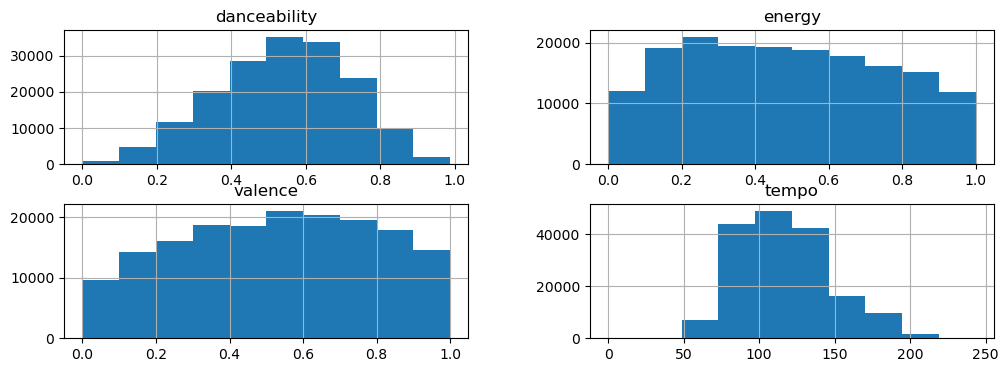

In [14]:
# Distribution of audio features
tracks[['danceability','energy','valence','tempo']].hist(figsize=(12,4))
plt.show()

count    170653.000000
mean         31.431794
std          21.826615
min           0.000000
25%          11.000000
50%          33.000000
75%          48.000000
max         100.000000
Name: popularity, dtype: float64


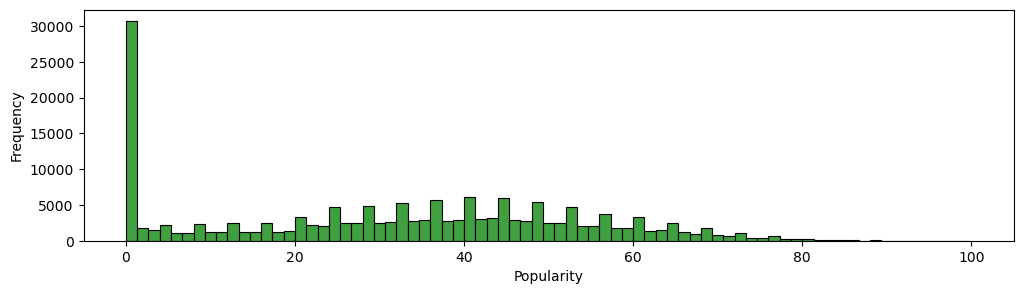

In [15]:
# Popularity analysis
print(tracks['popularity'].describe())
plt.figure(figsize=(12,3))
sns.histplot(data=tracks,x='popularity',color='green')
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.show()

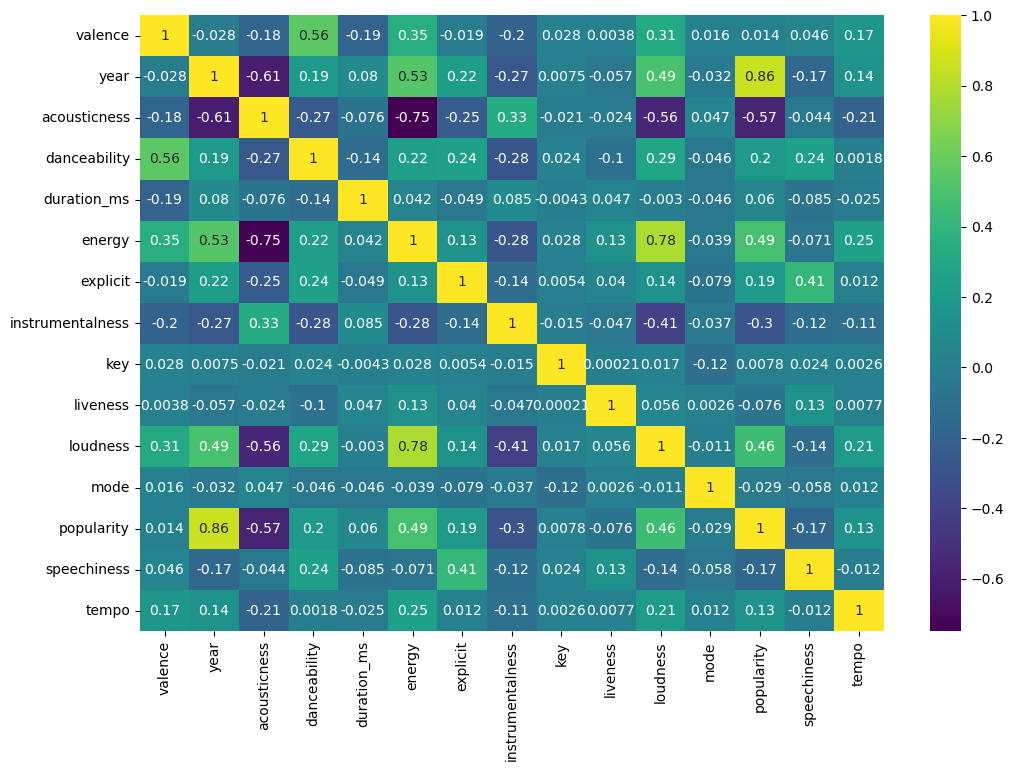

In [16]:
# Correlation between features
plt.figure(figsize=(12,8))
sns.heatmap(tracks.corr(numeric_only=True),annot=True,cmap='viridis')
plt.show()

In [17]:
# Genre analysis
genres.sort_values('popularity', ascending=False).head(10)

,mode,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
237,1,basshall,0.213167,0.81800,169799.166667,0.630167,0.000020,0.081067,-6.627833,0.134833,115.092500,0.588667,80.666667,2
2755,1,trap venezolano,0.044600,0.87700,231848.000000,0.777000,0.000035,0.086300,-4.246000,0.117000,102.020000,0.706000,80.000000,1
2533,1,south african house,0.043833,0.84700,311854.333333,0.562333,0.130339,0.075133,-7.719000,0.050733,123.676333,0.834333,80.000000,1
2778,0,turkish edm,0.008290,0.69800,186700.000000,0.719000,0.000004,0.326000,-4.923000,0.045500,120.062000,0.364000,80.000000,0
46,0,alberta hip hop,0.330000,0.88500,144000.000000,0.685000,0.000000,0.148000,-6.429000,0.062700,99.954000,0.937000,78.500000,11
536,0,chinese electropop,0.002570,0.66000,217088.000000,0.787000,0.000000,0.323000,-4.592000,0.032000,142.018000,0.199000,78.500000,1
37,0,afroswing,0.318450,0.71175,179995.375000,0.580187,0.000258,0.189950,-7.016687,0.195563,83.250125,0.676625,77.312500,11
1381,1,indie triste,0.946000,0.83000,207400.000000,0.159000,0.000020,0.362000,-14.461000,0.038300,104.950000,0.189000,77.000000,1
1239,1,guaracha,0.009030,0.74500,189818.000000,0.972000,0.465000,0.297000,-3.506000,0.077400,128.031000,0.556000,77.000000,7
2383,1,russian dance,0.005610,0.65300,198095.000000,0.945000,0.915000,0.439000,-2.634000,0.096000,126.093000,0.326000,77.000000,5


In [18]:
# Artist analysis
artist.sort_values('popularity', ascending=False).head(10)

,mode,count,acousticness,artists,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
20966,0,2,0.056300,Ritt Momney,0.399000,210463.0,0.491,0.000890,0.110000,-10.778000,0.0538,91.066000,0.151000,93.0,6
14354,1,1,0.090700,Lele Pons,0.905000,155825.0,0.686,0.000000,0.266000,-3.152000,0.0664,103.013000,0.963000,92.0,0
15070,0,2,0.310000,Los Legendarios,0.823000,213314.0,0.821,0.000004,0.143000,-3.402000,0.1660,99.999000,0.791000,90.0,8
11764,1,2,0.819000,Jerry Di,0.854000,197587.0,0.525,0.000000,0.146000,-4.426000,0.2140,97.054000,0.630000,89.0,1
7463,0,2,0.068600,Emilee,0.674000,176547.0,0.774,0.001880,0.393000,-7.567000,0.0892,112.050000,0.330000,88.0,11
28263,1,2,0.424000,salem ilese,0.738000,136839.0,0.621,0.000007,0.692000,-7.313000,0.0486,113.968000,0.715000,88.0,0
23687,0,1,0.068600,Surf Mesa,0.674000,176547.0,0.774,0.001880,0.393000,-7.567000,0.0892,112.050000,0.330000,88.0,11
213,0,3,0.166633,A7S,0.742667,168293.0,0.726,0.000000,0.154667,-5.921333,0.1980,121.296333,0.554667,87.0,8
14378,0,2,0.254000,Lenny Santos,0.752000,206760.0,0.716,0.000000,0.243000,-5.200000,0.0325,117.007000,0.553000,86.0,10
16453,1,1,0.018500,Master KG,0.880000,342613.0,0.483,0.000009,0.060700,-7.012000,0.0504,124.009000,0.827000,86.0,1


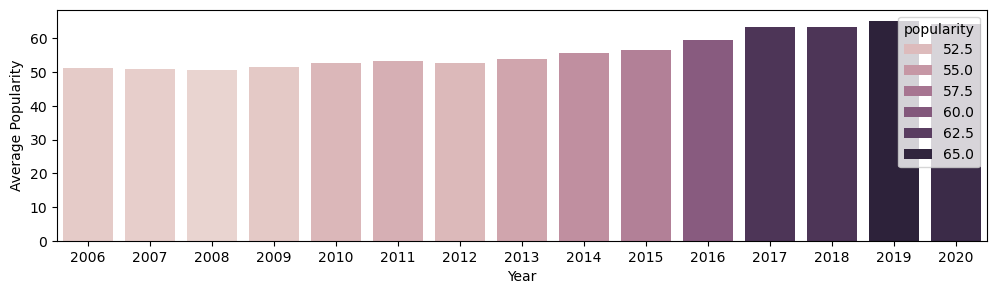

In [19]:
# Yearly trends
plt.figure(figsize=(12,3))
sns.barplot(data=year.tail(15),x='year',y='popularity',hue='popularity')
plt.xlabel("Year")
plt.ylabel("Average Popularity")
plt.show()

# Data Analysis

# Task 3.1: Distribution of Features (danceability, energy, tempo)

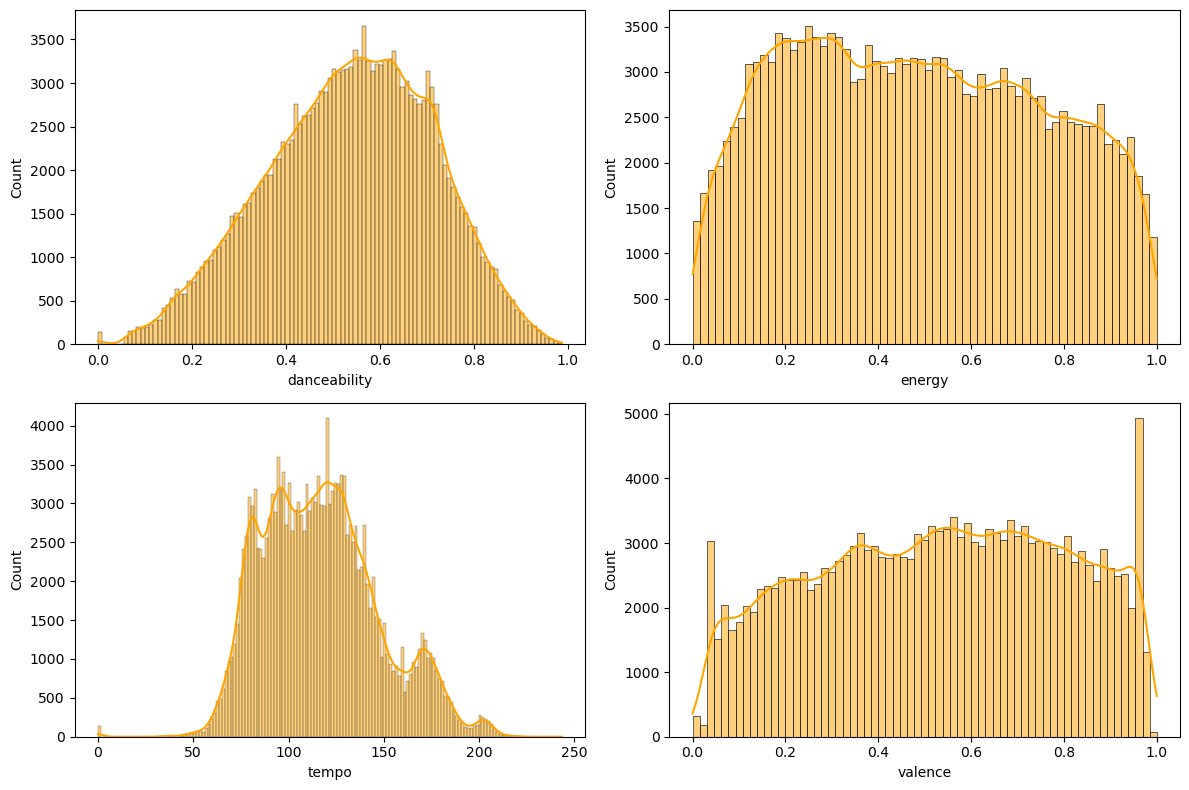

In [20]:
# Histograms with KDE
features = ['danceability', 'energy', 'tempo', 'valence']
plt.figure(figsize=(12,8))
for i, col in enumerate(features, 1):
    plt.subplot(2,2,i)
    sns.histplot(tracks[col],kde=True,color='orange')
plt.tight_layout()
plt.show()

# Task 3.2: Trends Over Time
Using data_by_year.csv to observe how music changes historically.

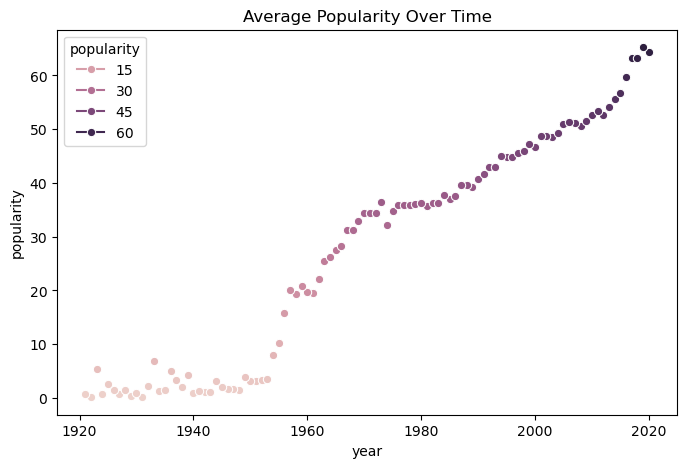

In [21]:
# Popularity trend line
plt.figure(figsize=(8,5))
sns.lineplot(data=year,x='year',y='popularity',marker='o',hue='popularity')
plt.title("Average Popularity Over Time")
plt.show()

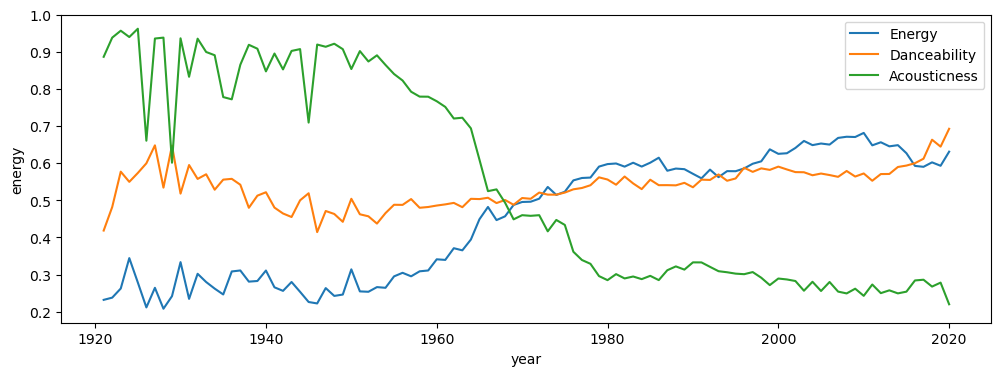

In [22]:
# Feature evolution over time
plt.figure(figsize=(12,4))
sns.lineplot(data=year,x='year',y='energy',label='Energy')
sns.lineplot(data=year,x='year',y='danceability',label='Danceability')
sns.lineplot(data=year,x='year',y='acousticness',label='Acousticness')
plt.legend()
plt.show()

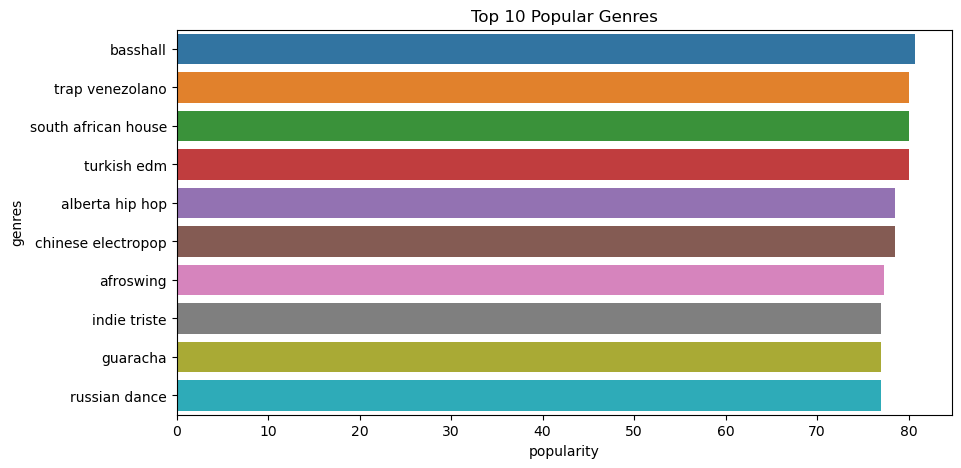

In [23]:
# Most popular genres
top_genres = genres.sort_values('popularity',ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(data=top_genres,x='popularity',y='genres',hue='genres')
plt.title('Top 10 Popular Genres')
plt.show()

# Task 3.3: Correlation Between Features

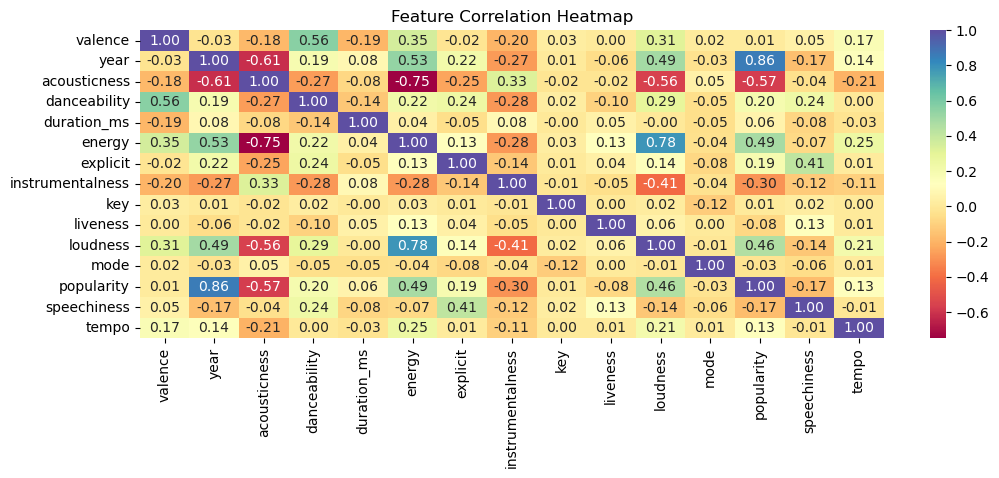

In [24]:
# Correlation heatmap
plt.figure(figsize=(12,4))
corr = tracks.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='Spectral',fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

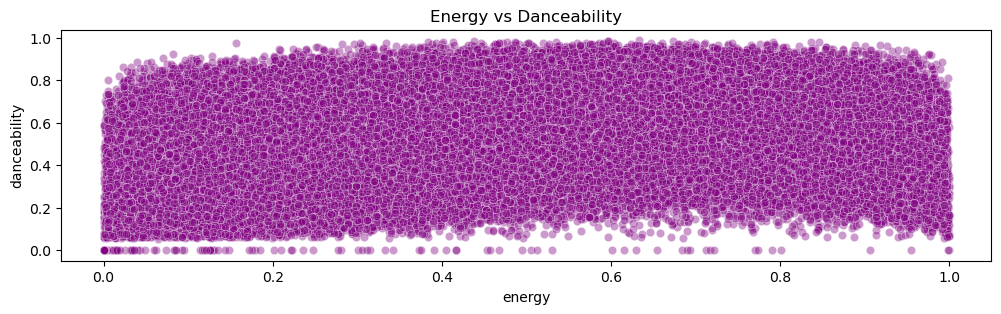

In [25]:
# Energy vs Danceability scatter
plt.figure(figsize=(12,3))
sns.scatterplot(data=tracks,x='energy',y='danceability',alpha=0.4,color='purple')
plt.title('Energy vs Danceability')
plt.show()

# Task 3.4: User Preferences & Listening Habits

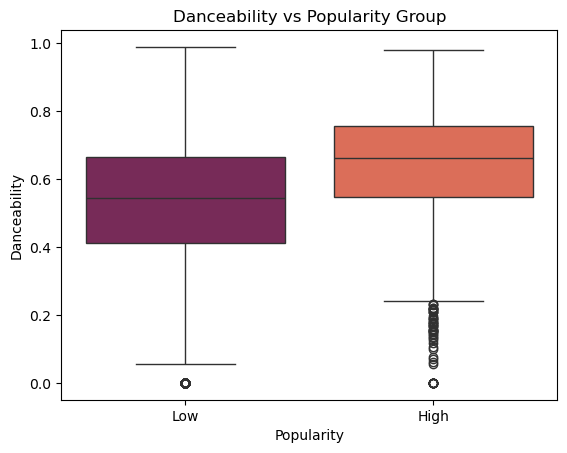

In [26]:
# Popular vs less popular songs (boxplot comparison)
tracks['pop_group'] = tracks['popularity'].apply(
    lambda x: 'High' if x >= 70 else 'Low')

sns.boxplot(data=tracks,x='pop_group',y='danceability',palette='rocket')
plt.xlabel('Popularity')
plt.ylabel('Danceability')
plt.title('Danceability vs Popularity Group')
plt.show()

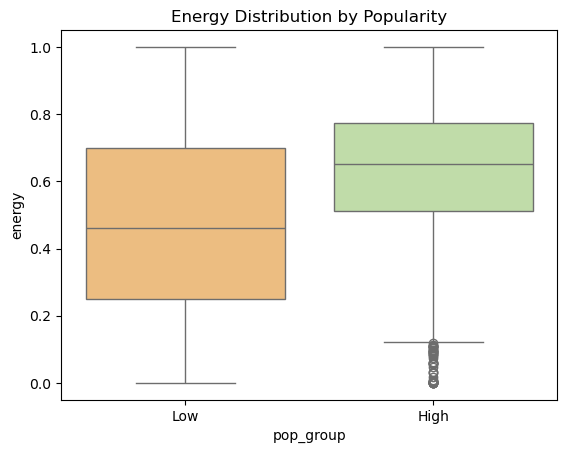

In [27]:
# Feature comparison for popularity
sns.boxplot(data=tracks,x='pop_group',y='energy',palette='Spectral')
plt.title("Energy Distribution by Popularity")
plt.show()

# Visualization
## Task 4.1: Basic Visualizations (Bar, Line, Scatter)

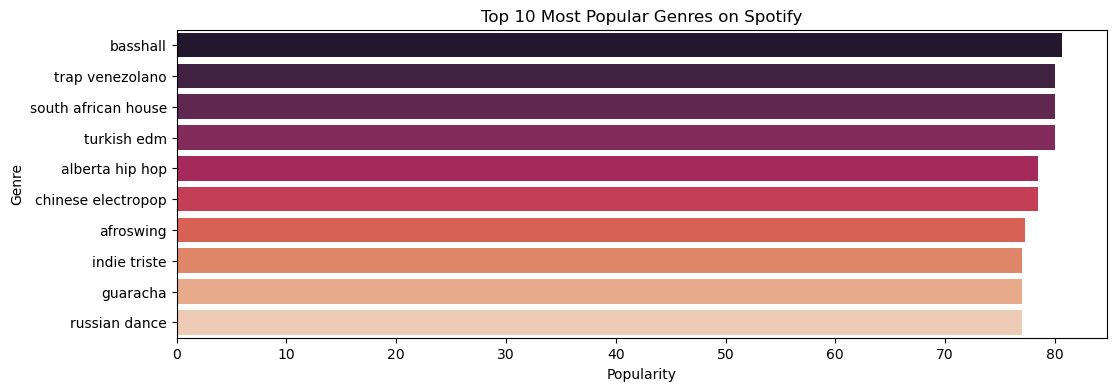

In [28]:
# Bar Chart — Top 10 Popular Genres
top_genres = genres.sort_values('popularity', ascending=False).head(10)
plt.figure(figsize=(12,4))
sns.barplot(data=top_genres,x='popularity',y='genres',palette='rocket')
plt.title("Top 10 Most Popular Genres on Spotify")
plt.xlabel("Popularity")
plt.ylabel("Genre")
plt.show()

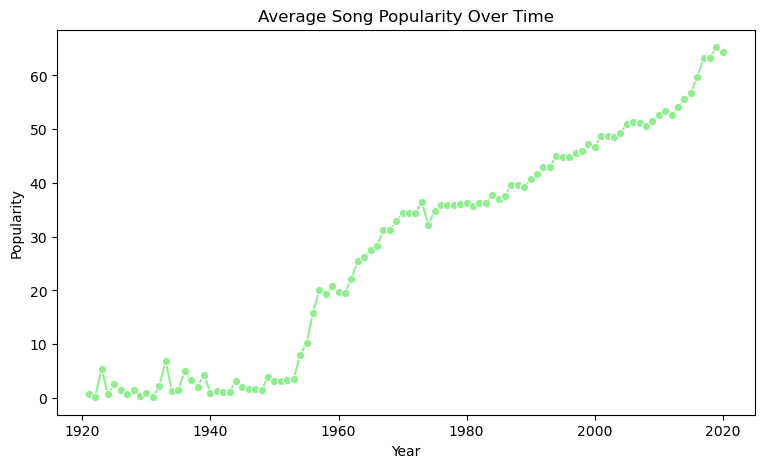

In [29]:
# Line Graph — Popularity Trend Over Time
plt.figure(figsize=(9,5))
sns.lineplot(data=year,x='year',y='popularity',marker='o',color='lightgreen')
plt.title("Average Song Popularity Over Time")
plt.xlabel("Year")
plt.ylabel("Popularity")
plt.show()

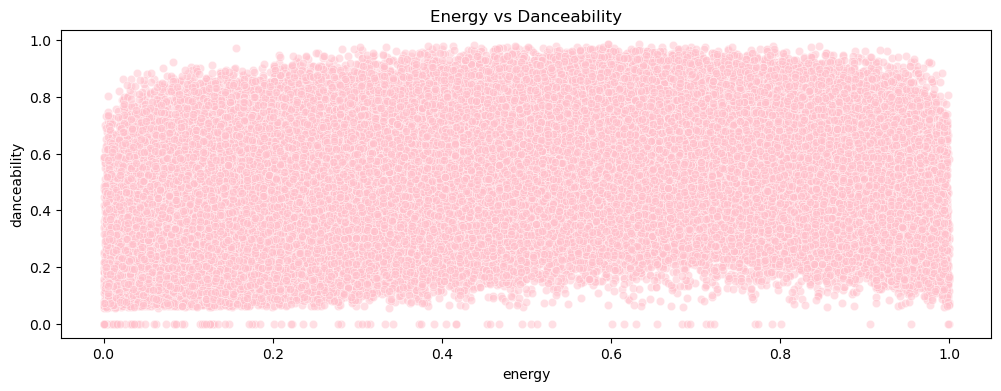

In [30]:
# Scatter Plot — Energy vs Danceability
plt.figure(figsize=(12,4))
sns.scatterplot(data=tracks,x='energy',y='danceability',alpha=0.5,color='pink')
plt.title("Energy vs Danceability")
plt.show()

# Task 4.2: Advanced Visualizations (Heatmaps, Pair Plots)

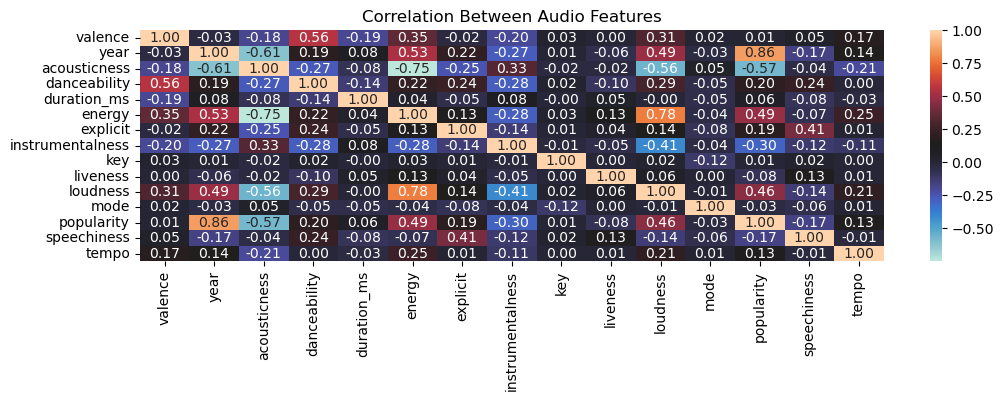

In [31]:
# Correlation Heatmap
plt.figure(figsize=(12,3))
corr = tracks.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='icefire',fmt='.2f')
plt.title('Correlation Between Audio Features')
plt.show()

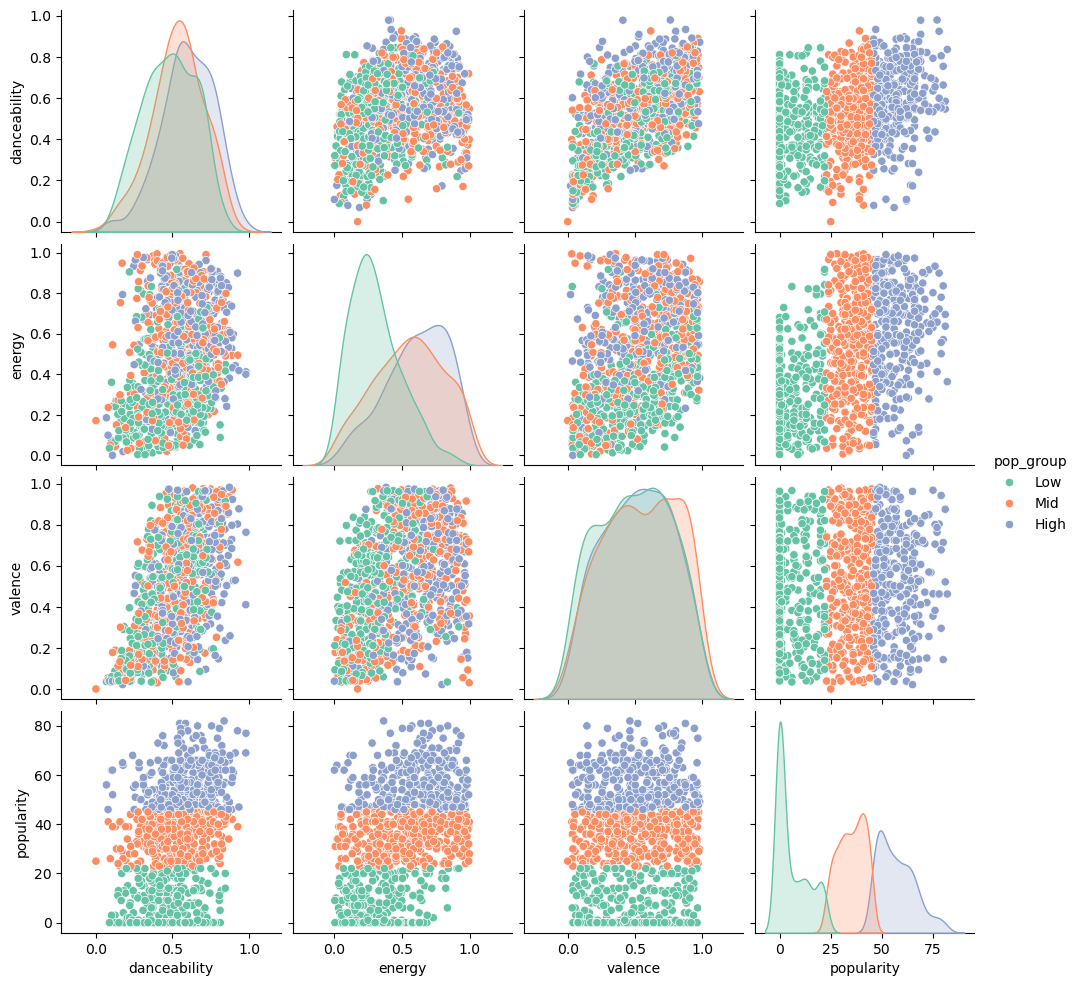

In [39]:
sample_tracks['pop_group'] = pd.qcut(sample_tracks['popularity'],3,labels=['Low','Mid','High'])
sns.pairplot(sample_tracks,vars=['danceability','energy','valence','popularity'],
             hue='pop_group',palette='Set2',
             diag_kind='kde')
plt.show()

# Key Insights from Popularity Group Pair Plot

## Popularity Segmentation Patterns
- High‑popularity tracks (blue) cluster at higher danceability and energy values, while low‑popularity tracks (green) spread across lower ranges.
- This indicates that musical attributes strongly differentiate popularity tiers.

## Feature Relationships Across Groups
- Danceability and energy show a positive correlation, especially for Mid and High popularity tracks.
- Valence (emotional positivity) has weaker alignment with popularity, suggesting it is not a primary driver.

## Distribution Insights
- KDE plots highlight that popularity groups overlap but with distinct tendencies: High popularity favors energetic, danceable tracks, while Low popularity is more dispersed.
- Mid popularity tracks (orange) often sit between extremes, showing transitional characteristics.

## Strategic Implications
- Artists: Focus on balancing danceability and energy to increase chances of higher popularity.
- Recommendation Systems: Incorporate multi‑feature interactions rather than single attributes for better prediction.
- Market Strategy: Emotional tone (valence) can complement success but should be paired with strong rhythmic and energetic qualities.

# Modeling and Predictions
## Task 5.1: Build Predictive Models to Forecast Song Popularity

In [33]:
# Prepare the data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Select numeric features only
features = [
    'danceability','energy','loudness','speechiness',
    'acousticness','instrumentalness','liveness',
    'valence','tempo','duration_ms'
]

X = tracks[features]
y = tracks['popularity']
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Scale features (important for regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Task 5.2: Evaluate Different Models

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression Results:
MAE: 13.11202616522743
RMSE: 16.307952651171533
R2: 0.44422210532623396


In [35]:
# Decision Tree
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2:", r2_score(y_test, y_pred_dt))

Decision Tree Results:
MAE: 14.255713769495962
RMSE: 19.645462578647304
R2: 0.19345815525316512


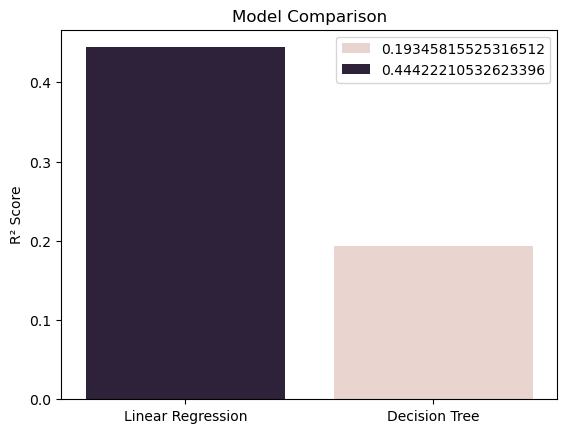

In [36]:
# Compare Model Performance (Visualization)
models = ['Linear Regression','Decision Tree']
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt)
]
sns.barplot(x=models,y=r2_scores,hue=r2_scores)
plt.ylabel("R² Score")
plt.title("Model Comparison")
plt.show()

# Task 5.3: Fine-Tune Models to Improve Accuracy

In [37]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

best_dt = grid.best_estimator_

y_pred_best = best_dt.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Tuned R2:", r2_score(y_test, y_pred_best))

Best Parameters: {'max_depth': 10, 'min_samples_split': 10}
Tuned R2: 0.5415446259348499


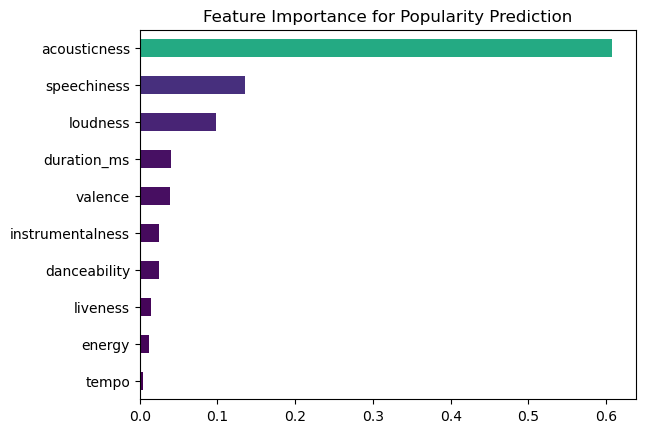

In [52]:
# Feature Importance (Very useful insight)
colors = plt.cm.viridis(importance.sort_values().values)
importance.sort_values().plot(kind='barh',color=colors)
plt.title("Feature Importance for Popularity Prediction")
plt.show()

# Conclusion
## Task 6.1: Key Findings

The analysis of Spotify’s dataset revealed several important patterns in music trends, user preferences, and track characteristics. Popular tracks generally exhibit higher energy, danceability, and loudness, indicating that upbeat and engaging songs tend to attract more listeners. Certain genres consistently dominate streaming counts, suggesting strong audience loyalty toward specific music styles. Additionally, newer releases show higher engagement levels compared to older tracks, highlighting the impact of recency on streaming behavior. Correlation analysis also indicated relationships between audio features (such as energy and loudness) and popularity scores.

## Task 6.2: Implications of the Results

These findings have practical implications for artists, producers, and music streaming platforms. Understanding which features contribute to track popularity can help artists tailor their music to audience preferences. Record labels can make data-driven decisions regarding genre investments and release strategies. For Spotify, insights into listener behavior can enhance recommendation systems, personalized playlists, and targeted promotions, ultimately improving user satisfaction and platform engagement.

## Task 6.3: Future Research Directions

Future research could explore deeper user-level analytics, such as individual listening patterns and personalized recommendation accuracy. Time-series analysis may help identify evolving trends and seasonal listening habits. Incorporating sentiment analysis of lyrics or social media feedback could provide richer context for popularity prediction. Additionally, applying machine learning models to predict hit songs based on audio features would further enhance predictive capabilities.